In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Supprimer les warning
import warnings
warnings.filterwarnings("ignore")

### <font color = 'teal'>Importer et Lire les données<font>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# importer les données
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/Doc 2/Bank_Data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Affichage des donnees
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,28,management,single,university.degree,yes,no,cellular,jun,thu,339,3,6,2,success,yes
1,55,retired,married,basic.4y,yes,no,cellular,aug,fri,137,1,3,1,success,yes
2,36,admin.,married,university.degree,no,no,cellular,jun,mon,174,1,3,1,success,yes
3,55,management,married,university.degree,no,no,cellular,aug,mon,372,3,999,0,nonexistent,yes
4,35,services,married,high.school,no,no,cellular,apr,thu,1034,2,999,0,nonexistent,yes


#### <font color = "bisque">Concernant les données<font>
Les données sont liées aux campagnes de marketing direct (appels téléphoniques) d'une institution bancaire portugaise. L'objectif de la classification est de prédire si le client souscrira un dépôt à terme (term deposit) (variable y). Les données sont issues de [UCI repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)


#### Description des variables du jeu de données "Bank Marketing"

Ce jeu de données contient des informations issues de campagnes de marketing téléphonique réalisées par une banque portugaise. L'objectif est de prédire si un client souscrira à un dépôt à terme (`y`).

| Variable           | Type          | Description |
|--------------------|---------------|-------------|
| `age`              | Numérique     | Âge du client (en années). |
| `job`              | Catégorielle  | Profession du client (ex. : 'admin.', 'technician', 'services', etc.). |
| `marital`          | Catégorielle  | Statut marital du client (ex. : 'married', 'single', 'divorced'). |
| `education`        | Catégorielle  | Niveau d'éducation du client (ex. : 'basic.4y', 'high.school', 'university.degree'). |
| `default`          | Binaire       | Le client a-t-il un crédit en défaut ? ('yes', 'no'). |
| `housing`          | Binaire       | Le client a-t-il un prêt immobilier ? ('yes', 'no'). |
| `loan`             | Binaire       | Le client a-t-il un prêt personnel ? ('yes', 'no'). |
| `contact`          | Catégorielle  | Type de contact utilisé pour la communication ('cellular', 'telephone'). |
| `month`            | Catégorielle  | Mois du dernier contact client (ex. : 'may', 'aug', 'nov'). |
| `day_of_week`      | Catégorielle  | Jour de la semaine du dernier contact (ex. : 'mon', 'tue', ...). |
| `duration`         | Numérique     | Durée du dernier contact (en secondes). **Important : cette variable est très corrélée à la cible `y`**. |
| `campaign`         | Numérique     | Nombre de contacts effectués durant cette campagne. |
| `pdays`            | Numérique     | Nombre de jours depuis le dernier contact d'une campagne précédente (999 signifie "jamais contacté auparavant"). |
| `previous`         | Numérique     | Nombre de contacts effectués avant cette campagne. |
| `poutcome`         | Catégorielle  | Résultat de la campagne marketing précédente ('success', 'failure', 'nonexistent'). |
| `y`                | Cible (binaire) | Le client a-t-il souscrit à un dépôt à terme ? ('yes', 'no'). |


In [6]:
# dimension des données
df.shape

(11640, 15)

In [7]:
# infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11640 entries, 0 to 11639
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          11640 non-null  int64 
 1   job          11640 non-null  object
 2   marital      11640 non-null  object
 3   education    11640 non-null  object
 4   housing      11640 non-null  object
 5   loan         11640 non-null  object
 6   contact      11640 non-null  object
 7   month        11640 non-null  object
 8   day_of_week  11640 non-null  object
 9   duration     11640 non-null  int64 
 10  campaign     11640 non-null  int64 
 11  pdays        11640 non-null  int64 
 12  previous     11640 non-null  int64 
 13  poutcome     11640 non-null  object
 14  y            11640 non-null  object
dtypes: int64(5), object(10)
memory usage: 1.3+ MB


### <font color = 'gold'>Exploration des données<font>

##### <font color = 'bisque'>Séléction des variables

In [8]:
# sélection des variables catégorielles en utilisant select_dtypes
cat_data = df.select_dtypes(include = 'object')
cat_data.head()

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome,y
0,management,single,university.degree,yes,no,cellular,jun,thu,success,yes
1,retired,married,basic.4y,yes,no,cellular,aug,fri,success,yes
2,admin.,married,university.degree,no,no,cellular,jun,mon,success,yes
3,management,married,university.degree,no,no,cellular,aug,mon,nonexistent,yes
4,services,married,high.school,no,no,cellular,apr,thu,nonexistent,yes


In [9]:
# sélection des variables quantitatives en utilisant select_dtypes
num_data = df.select_dtypes(include = 'number')
num_data.head()

,age,duration,campaign,pdays,previous
0,28,339,3,6,2
1,55,137,1,3,1
2,36,174,1,3,1
3,55,372,3,999,0
4,35,1034,2,999,0


##### <font color = 'bisque'> Exploration des variables catégorielles

In [10]:
# décrire les variables catégorielles
cat_data.describe().transpose()


,count,unique,top,freq
job,11640,12,admin.,3103
marital,11640,4,married,6853
education,11640,8,university.degree,3703
housing,11640,3,yes,6146
loan,11640,3,no,9650
contact,11640,2,cellular,8180
month,11640,10,may,3284
day_of_week,11640,5,thu,2518
poutcome,11640,3,nonexistent,9346
y,11640,2,no,7000


In [11]:
# fonction de countplot
def countplot_func(col):
  val = df[col].value_counts()
  plt.figure(figsize=(25,3))
  sns.barplot(x=val.index, y=val.values, hue = val.index, palette = sns.hls_palette())
  plt.show()

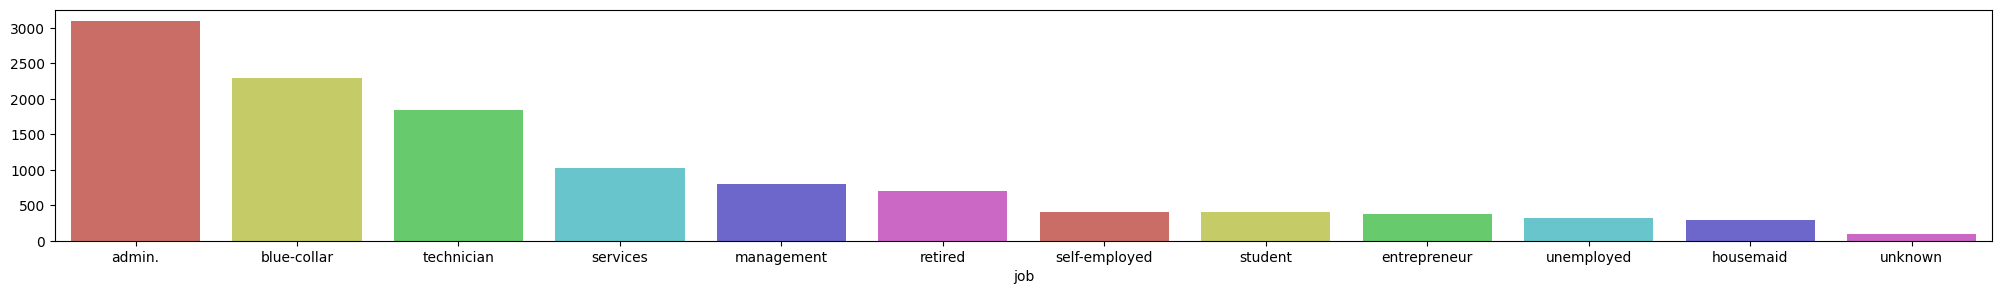

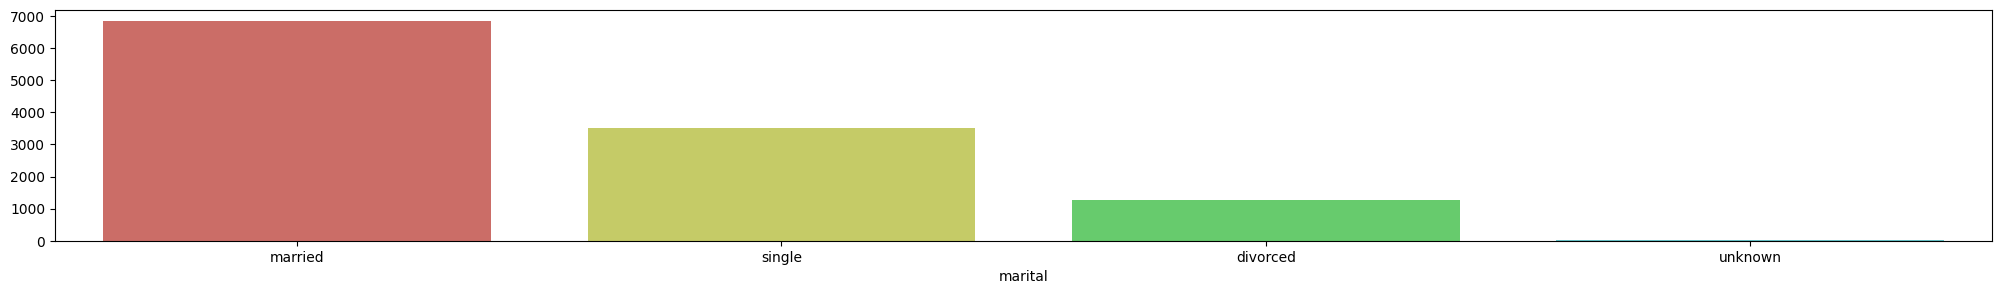

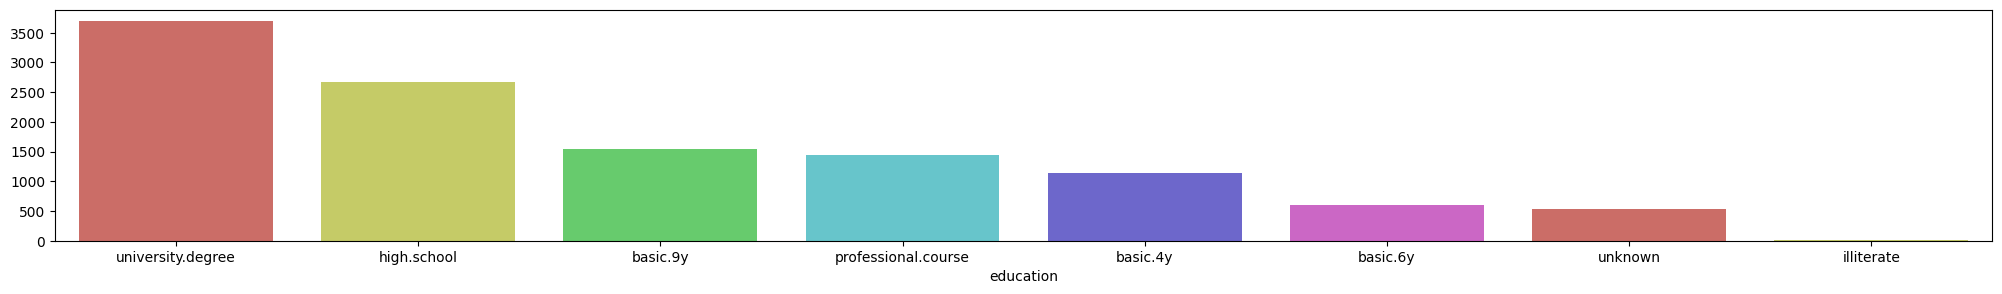

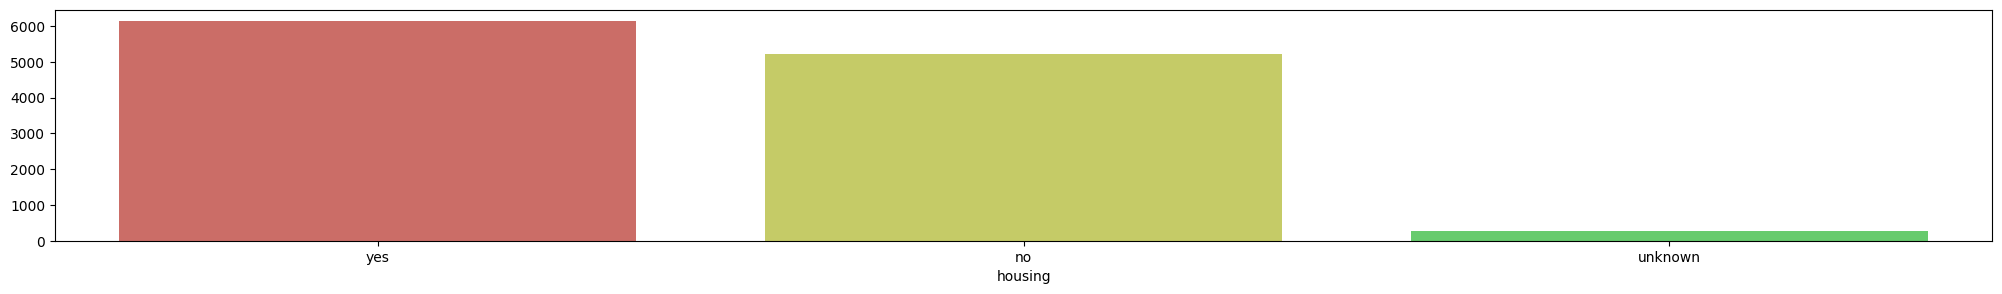

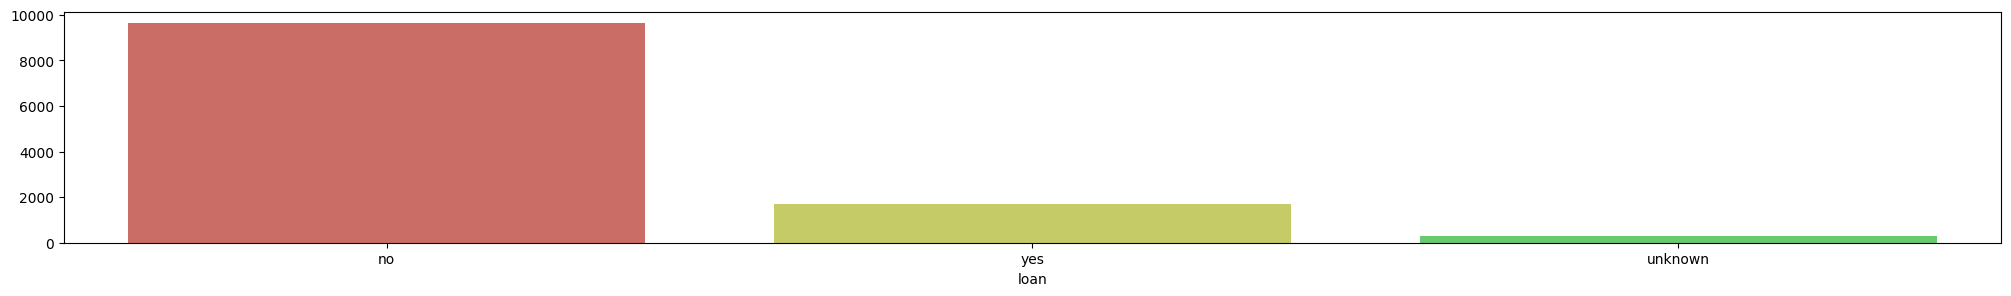

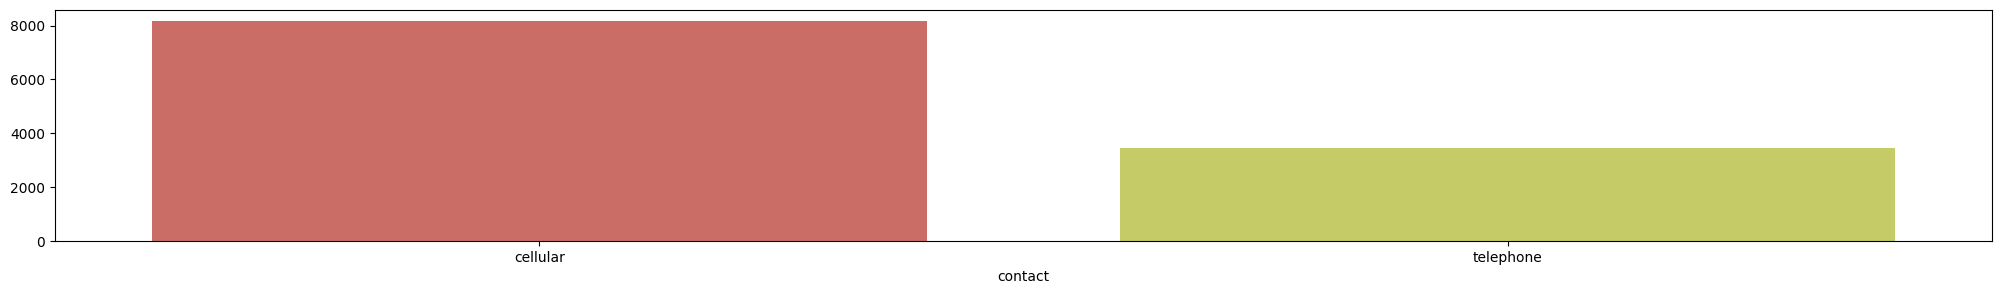

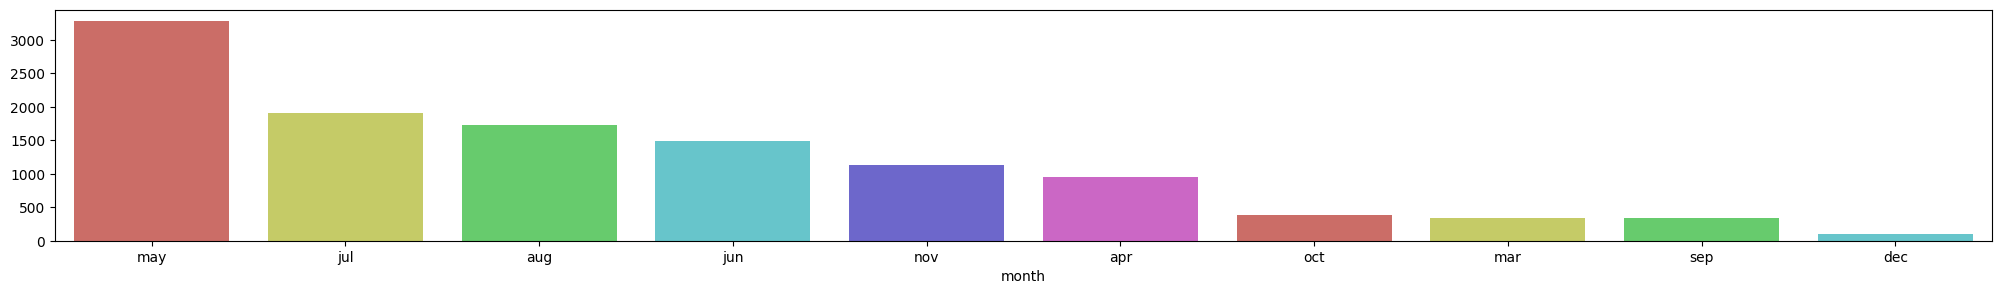

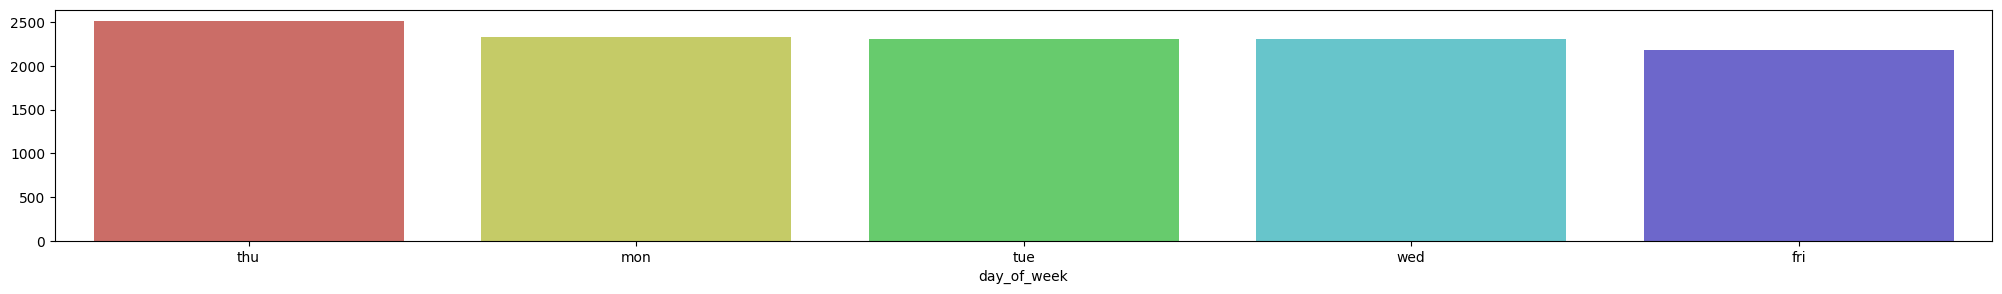

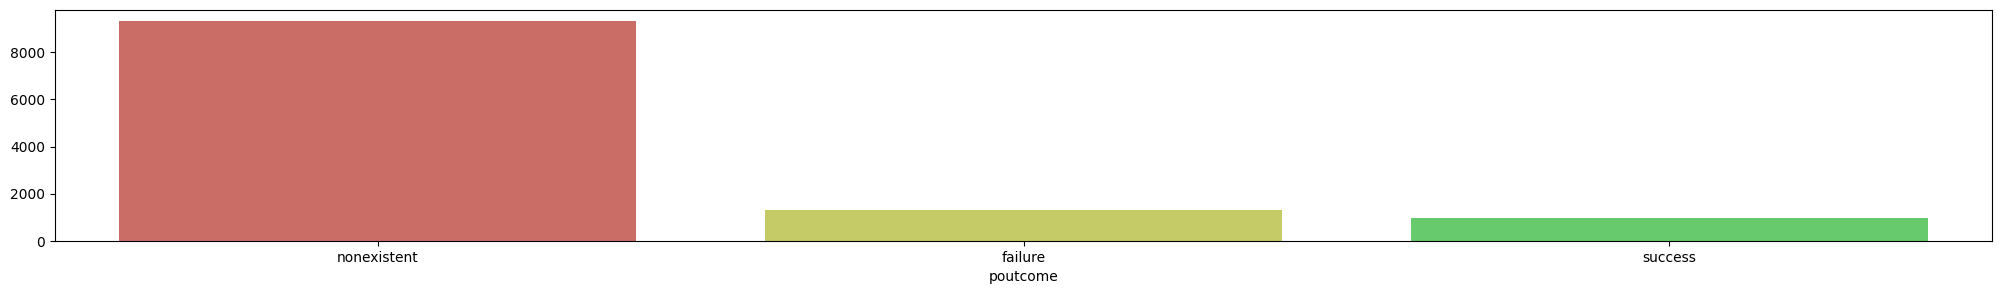

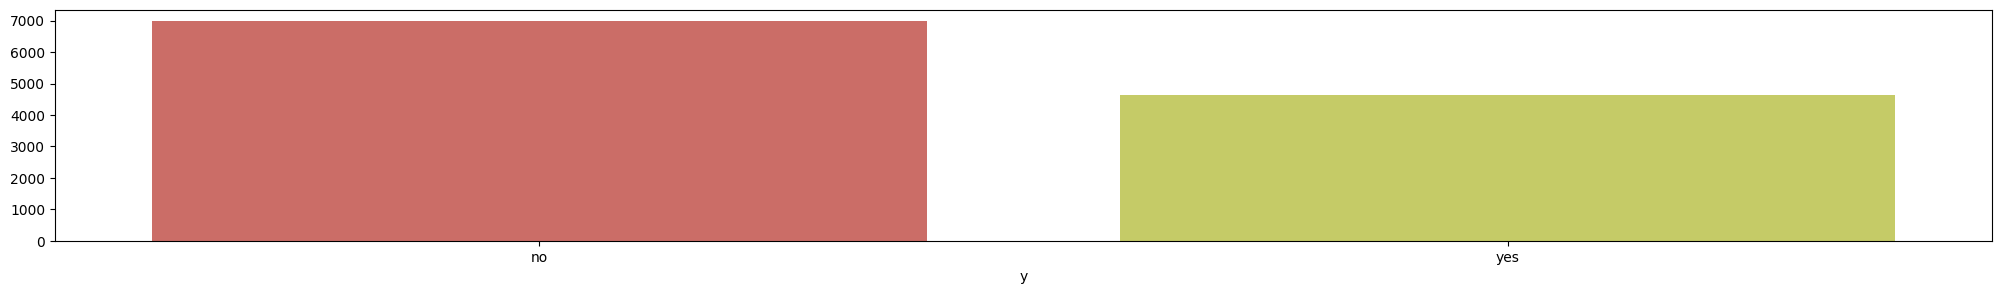

In [12]:
# Countplots de toutes les variables
for col in cat_data.columns:
  countplot_func(col)

##### <font color = 'bisque'> Exploration des variables quantitatives

In [13]:
# décrire les variables quantitatives
num_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,11640.0,40.325515,11.639351,17.0,32.0,38.0,48.0,98.0
duration,11640.0,354.709021,341.481865,1.0,131.0,238.0,466.0,4199.0
campaign,11640.0,2.378608,2.377445,1.0,1.0,2.0,3.0,39.0
pdays,11640.0,907.797766,286.811601,0.0,999.0,999.0,999.0,999.0
previous,11640.0,0.278093,0.656532,0.0,0.0,0.0,0.0,6.0


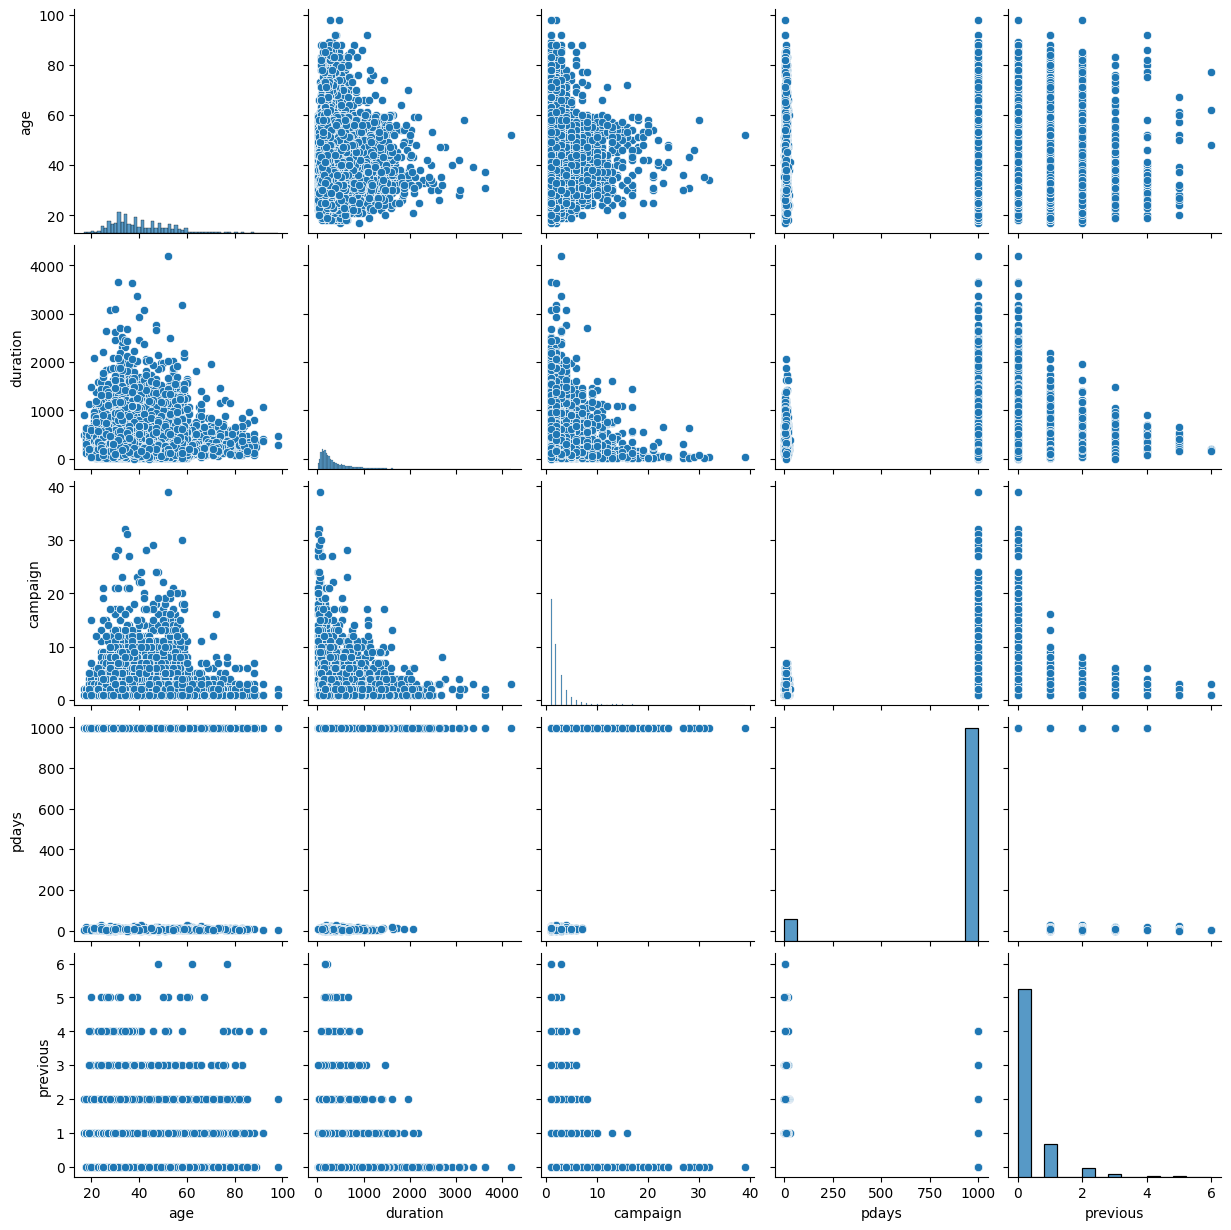

In [14]:
# pairplot ca fonctionne uniquement pour
sns.pairplot(num_data)
plt.show()

In [15]:
# fonction boxplots
def boxplot_func(col):
  plt.figure(figsize=(25,3))
  sns.boxplot(x=df[col])
  plt.show()

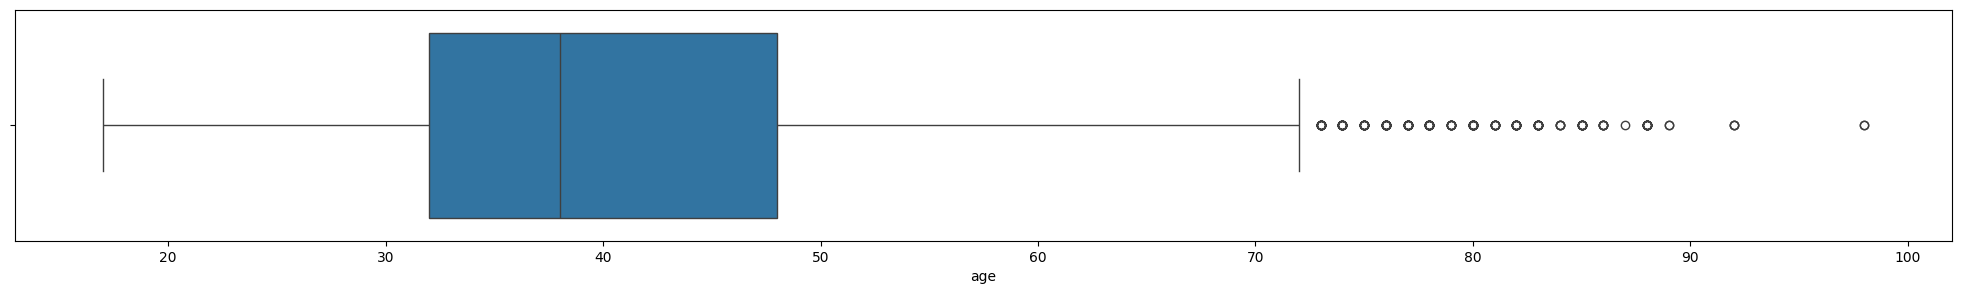

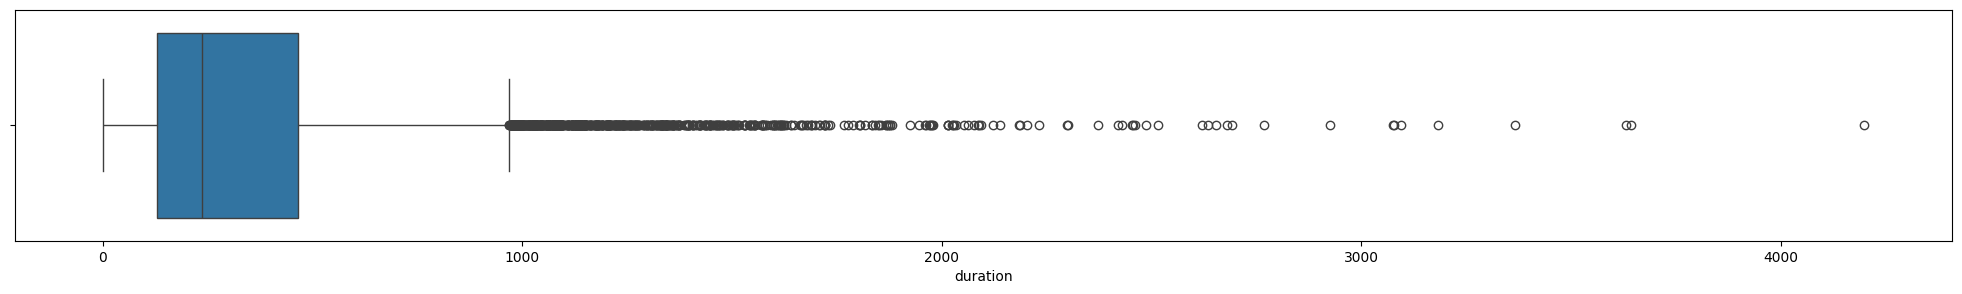

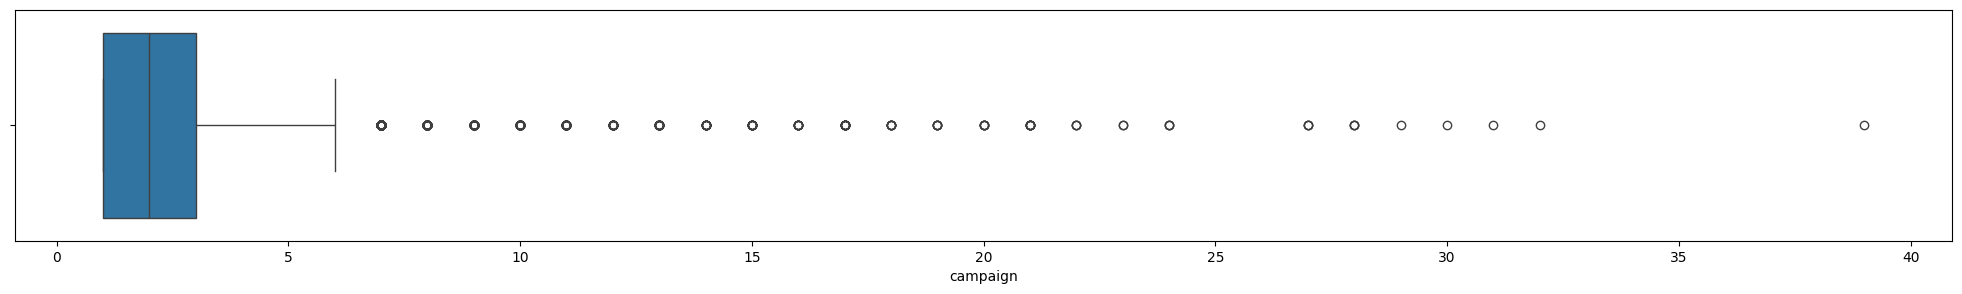

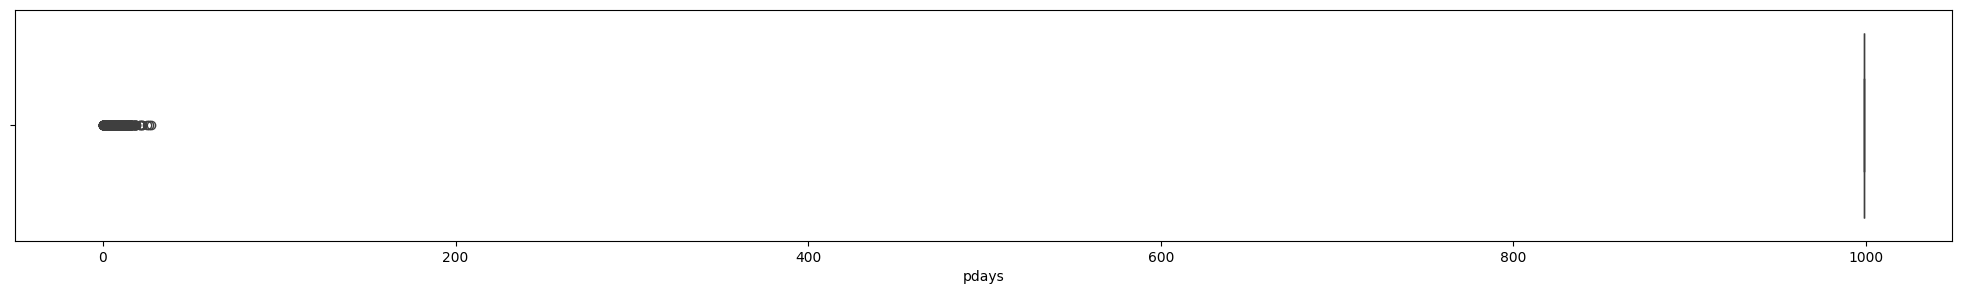

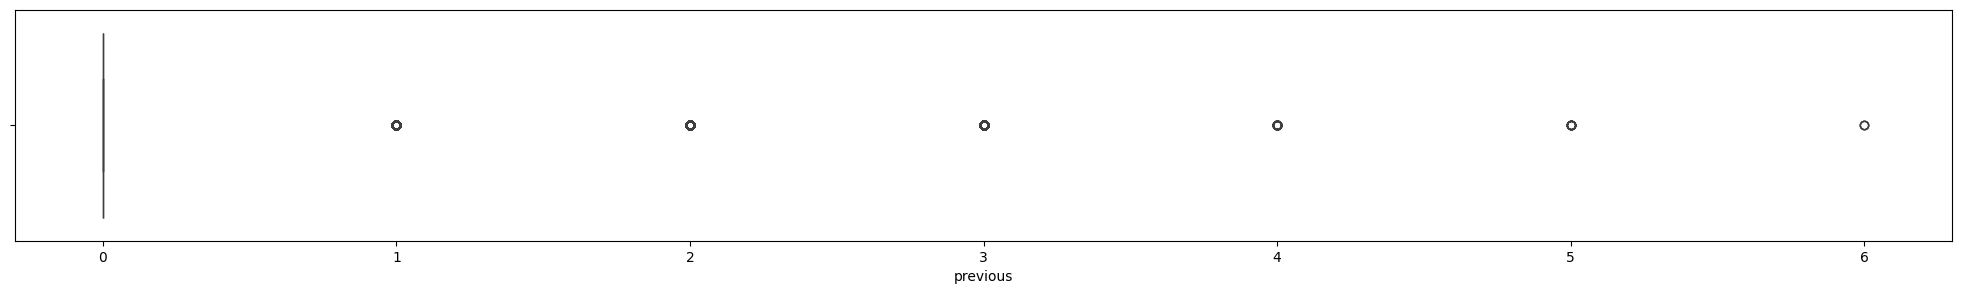

In [16]:
# boxplots des toutes les variables quantitatives
for col in num_data.columns:
  boxplot_func(col)

### <font color = 'gold'>Preparation des données<font>



##### <font color = 'bisque'> Preparation des variables catégorielles

In [17]:
from numpy.random import chisquare
# Encoder les variables catégorielles
from sklearn.preprocessing import LabelEncoder
for col in cat_data.columns:
  df[col] = LabelEncoder().fit_transform(df[col])

df.head()


,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,28,4,2,6,2,0,0,4,2,339,3,6,2,2,1
1,55,5,1,0,2,0,0,1,0,137,1,3,1,2,1
2,36,0,1,6,0,0,0,4,1,174,1,3,1,2,1
3,55,4,1,6,0,0,0,1,1,372,3,999,0,1,1
4,35,7,1,3,0,0,0,0,2,1034,2,999,0,1,1


##### <font color = 'bisque'> Preparation des quantitatives

In [18]:
# Fonction d'imputation des valeurs aberrantes par la médiane
def imputation_func(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  df[col] = np.where((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)), df[col].median(),df[col])

In [19]:
# imputer les valeurs aberrantes sur les variables  (age, duration, campaign )
for col in num_data.columns[:3]:
  imputation_func(df, col)

In [20]:
# réafficher les boxplots



##### <font color = 'bisque'> Fractionnement et normalisation

In [21]:
# Fractionner les données en variables prédicteurs (x) et variable cibel(y)
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
x[:5]

array([[ 28.,   4.,   2.,   6.,   2.,   0.,   0.,   4.,   2., 339.,   3.,
          6.,   2.,   2.],
       [ 55.,   5.,   1.,   0.,   2.,   0.,   0.,   1.,   0., 137.,   1.,
          3.,   1.,   2.],
       [ 36.,   0.,   1.,   6.,   0.,   0.,   0.,   4.,   1., 174.,   1.,
          3.,   1.,   2.],
       [ 55.,   4.,   1.,   6.,   0.,   0.,   0.,   1.,   1., 372.,   3.,
        999.,   0.,   1.],
       [ 35.,   7.,   1.,   3.,   0.,   0.,   0.,   0.,   2., 238.,   2.,
        999.,   0.,   1.]])

In [22]:
# normaliser les données en utilisant StandardScaler (Z = X/(mean(X)-std(X)))
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x = scaler.fit_transform(x)
x[:5]

array([[-1.11568749,  0.0559783 ,  1.30349852,  1.00361413,  0.93415547,
        -0.44473072, -0.65037134, -0.08468109, -0.01301696,  0.23070297,
         0.83909318, -3.14435156,  2.62284274,  2.3198429 ],
       [ 1.47646787,  0.3327784 , -0.32203424, -1.79795311,  0.93415547,
        -0.44473072, -0.65037134, -1.3030839 , -1.44920121, -0.70458482,
        -0.81619783, -3.15481184,  1.09962319,  2.3198429 ],
       [-0.34764145, -1.05122209, -0.32203424,  1.00361413, -1.09733816,
        -0.44473072, -0.65037134, -0.08468109, -0.73110909, -0.53326973,
        -0.81619783, -3.15481184,  1.09962319,  2.3198429 ],
       [ 1.47646787,  0.0559783 , -0.32203424,  1.00361413, -1.09733816,
        -0.44473072, -0.65037134, -1.3030839 , -0.73110909,  0.38349751,
         0.83909318,  0.31800022, -0.42359636,  0.06282423],
       [-0.44364721,  0.88637859, -0.32203424, -0.39716949, -1.09733816,
        -0.44473072, -0.65037134, -1.70921817, -0.01301696, -0.23694092,
         0.01144767,  0.31

In [23]:
# splitter les données en train, val et test
# train (80%), val(10%) et test(10%)
#train : données d'entrainement, val: données utiliser pour évaluer chaque modèle et test: données pour tester le modèle le plus performant
from sklearn.model_selection import train_test_split

x_train, x_vt, y_train, y_vt = train_test_split(x, y, train_size = 0.8, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_train, y_train, train_size = 0.8, random_state=42)

### <font color = 'teal'>Logistic Regression<font>

In [24]:
# Recherche des paramètres optimaux pour la logistic regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
# dictionnaire params
params={"C":np.logspace(-3,3,7),"penalty": ['l1','l2'],'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']}
# instantier le modèle Logistic regression
lg=LogisticRegression()
# instantier le modèle gridsearch
grid=GridSearchCV(lg,params,cv=5)
# lancer la recherche
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag',
                                    'saga']})

In [25]:
# Afficher les paramètres optimaux


In [26]:
# Entrainer la logistic regression en utilisant les paramètres optimaux


##### <font color ='bisque'>Evaluation du Logistic Regression<font>

In [27]:
# Accuracy et F1 score du modèle sur les données de validation
from sklearn.metrics import f1_score, accuracy_score


In [28]:
# Accuracy sur les données train


In [29]:
# Importer ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# y_pred:  prédictions du modèle sur les données validation
y_pred = lg.predict(x_val)
# Confusion matrix
cnf_matr = confusion_matrix(y_val, y_pred, labels=[0,1])

# Utiliser ConfusionMatrixDisplay pour visualiser la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr,
                              display_labels=['Pas de Depôt(0)','Depôt(1)'])
disp.plot() # Afficher la matrice de confusion
plt.title('Matrice de confusion') # Définir le titre
plt.show() # Afficher la figure

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### <font color = 'teal'>Support Vectors Machines (SVM)<font>

In [ ]:
# Recherche des paramètres optimaux pour le svm
from sklearn.svm import SVC
# dictionnaire des params
param_ = {'C':np.logspace(-1,3,5), 'kernel':['linear','rbf']}
# instantier le modèle svm
svm = SVC()
# instantier le modèle gridsearch
grid_ = GridSearchCV(svm, param_, cv =5)
# entrainer le modèle
grid_.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux


In [ ]:
# Entrainer svm en utilisant les paramètres optimaux, C = 1.0, kernel ='rbf'


##### <font color ='bisque'>Evaluation du SVM<font>

In [ ]:
# Accuracy et F1 score du modèle sur les données de validation


In [ ]:
# Accuracy sur les données train


In [ ]:
# y_pred_:  prédictions du modèle sur les données validation
y_pred_ = SVM_.predict(x_val)
# Confusion matrix
cnf_matr_ = confusion_matrix(y_val, y_pred_, labels=[0,1])

# Utiliser ConfusionMatrixDisplay pour visualiser la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr_,
                              display_labels=['Pas de Depôt(0)','Depôt(1)'])
disp.plot() # Afficher la matrice de confusion
plt.title('Matrice de confusion') # Définir le titre
plt.show() # Afficher la figure

### <font color = 'teal'>Decision Tree<font>

In [ ]:
# Recherche des paramètres optimaux pour le Decision Tree
from sklearn.tree import DecisionTreeClassifier
# dictionnaire des params
param__ = {'criterion':['gini','entropy'],'max_depth':np.arange(3,15)}
# instantier le modèle Decision Tree
dt = DecisionTreeClassifier()
# instantier le modèle gridsearch
grid__ = GridSearchCV(dt, param__, cv = 5)
# entrainer le modèle
grid__.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux


In [ ]:
# Entrainer le modèle en utilisant les paramètres optimaux


##### <font color ='bisque'>Evaluation du Decision Tree<font>

In [ ]:
# Accuracy et F1 score du modèle sur les données de validation


In [ ]:
# Accuracy sur les données train


In [ ]:
# y_pred__:  prédictions du modèle sur les données validation
y_pred__ = dt.predict(x_val)
# Confusion matrix
cnf_matr__= confusion_matrix(y_val, y_pred__, labels=[0,1])

# Utiliser ConfusionMatrixDisplay pour visualiser la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr__,
                              display_labels=['Pas de Depôt(0)','Depôt(1)'])
disp.plot() # Afficher la matrice de confusion
plt.title('Matrice de confusion') # Définir le titre
plt.show() # Afficher la figure

### <font color ='bisque'>Tester le modèle le plus performant<font>